In [20]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

import numpy as np

In [51]:
data = pd.read_csv('data/clear_parse_json.csv')
data

,sentiment,repeated_chars_count,has_digit_prefix,text_clean,text_len,word_count,avg_word_len,unique_word_ratio,json_parse
0,1,0,0,Толя конечно Герой Успехов во всём и здоровья ...,110,16,5.937500,1.000000,"{'positive_word_count': 4, 'negative_word_coun..."
1,0,1,1,у нас искусственный интеллект сейчас даже там ...,183,31,4.935484,0.903226,"{'positive_word_count': 4, 'negative_word_coun..."
2,1,0,0,Мне радостно что наше многогранное Отечество п...,99,13,6.692308,1.000000,"{'positive_word_count': 4, 'negative_word_coun..."
3,-1,0,0,Ну и говно,10,3,2.666667,1.000000,"{'positive_word_count': 0, 'negative_word_coun..."
4,1,0,0,@ Спасибо подписался,20,3,6.000000,1.000000,"{'positive_word_count': 1, 'negative_word_coun..."
...,...,...,...,...,...,...,...,...,...
3025,0,0,0,Ты смотрела сериалДесять дней до весны,38,6,5.500000,1.000000,"{'positive_word_count': 0, 'negative_word_coun..."
3026,1,0,0,Пусть Ангелы оберегают наших воинов,35,5,6.200000,1.000000,"{'positive_word_count': 1, 'negative_word_coun..."
3027,-1,0,0,Клоун не может быть политиком с илу скудтумия,45,8,4.750000,1.000000,"{'positive_word_count': 0, 'negative_word_coun..."
3028,1,0,0,Ирина согласна Но досмотрю до конца И всем сов...,50,9,4.666667,1.000000,"{'positive_word_count': 2, 'negative_word_coun..."


In [52]:
import ast

data['json_parse'] = data['json_parse'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

expanded = pd.json_normalize(data['json_parse'])
data = pd.concat([data, expanded], axis=1)

In [53]:
data = data.drop(columns = ['json_parse','text_clean','text_len','target_entity'])

In [54]:
data

,sentiment,repeated_chars_count,has_digit_prefix,word_count,avg_word_len,unique_word_ratio,positive_word_count,negative_word_count,neutral_word_count,negation_count,intensifier_count,emotional_shift,aggression_flag,emotional_intensity,rhetorical_question_count,appeal_flag,religious_lexicon_flag,political_lexicon_flag
0,1,0,0,16,5.937500,1.000000,4,0,3,0,2,0.0,0.0,2.0,0,0.0,1.0,0.0
1,0,1,1,31,4.935484,0.903226,4,0,6,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0
2,1,0,0,13,6.692308,1.000000,4,0,0,0,0,0.0,0.0,1.0,0,1.0,0.0,0.0
3,-1,0,0,3,2.666667,1.000000,0,1,0,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0
4,1,0,0,3,6.000000,1.000000,1,0,1,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3025,0,0,0,6,5.500000,1.000000,0,0,4,0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
3026,1,0,0,5,6.200000,1.000000,1,0,2,0,0,0.0,0.0,1.0,0,0.0,1.0,0.0
3027,-1,0,0,8,4.750000,1.000000,0,0,4,1,0,0.0,0.0,1.0,0,0.0,0.0,1.0
3028,1,0,0,9,4.666667,1.000000,2,0,3,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0


In [55]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [56]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sentiment                  3030 non-null   int64  
 1   repeated_chars_count       3030 non-null   int64  
 2   has_digit_prefix           3030 non-null   int64  
 3   word_count                 3030 non-null   int64  
 4   avg_word_len               3030 non-null   float64
 5   unique_word_ratio          3030 non-null   float64
 6   positive_word_count        3030 non-null   int64  
 7   negative_word_count        3030 non-null   int64  
 8   neutral_word_count         3030 non-null   int64  
 9   negation_count             3030 non-null   int64  
 10  intensifier_count          3030 non-null   int64  
 11  emotional_shift            2932 non-null   float64
 12  aggression_flag            2932 non-null   float64
 13  emotional_intensity        2932 non-null   float64
 14  rhe

<Axes: >

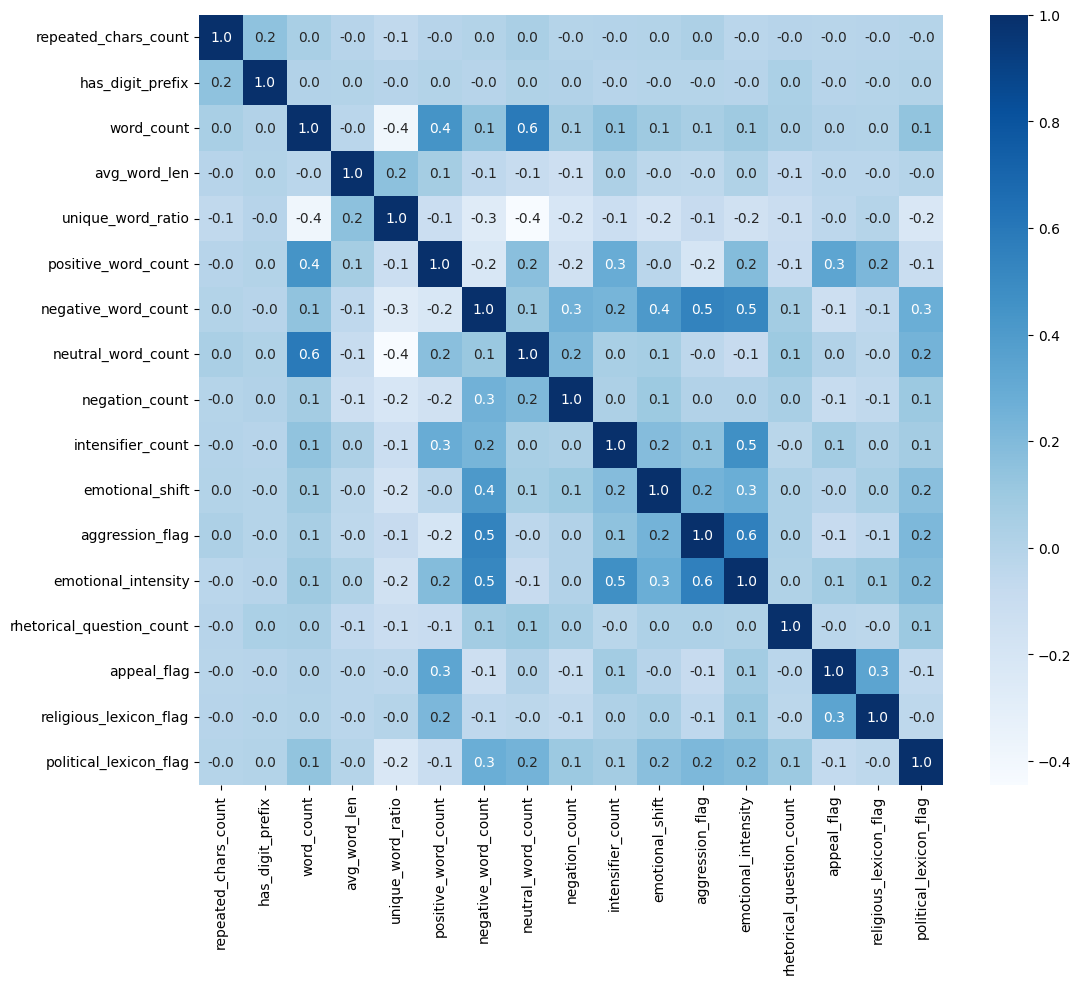

In [58]:
corr_matrix = data.iloc[:,1:].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    data = corr_matrix,
    fmt='.1f', annot=True,
    cmap='Blues'
)



In [59]:
data['sentiment'].value_counts(normalize=True)

sentiment
 1    0.453465
 0    0.374587
-1    0.171947
Name: proportion, dtype: float64

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X = data.drop(columns = 'sentiment')
y = data['sentiment']

X_train, X_test, y_train,y_test = train_test_split(X, y, stratify=y, random_state=42,test_size=0.2)


In [62]:
import sys
sys.path.append('..')

from lib import plot_hist_boxplot
from lib import normalize_data_with_scalers

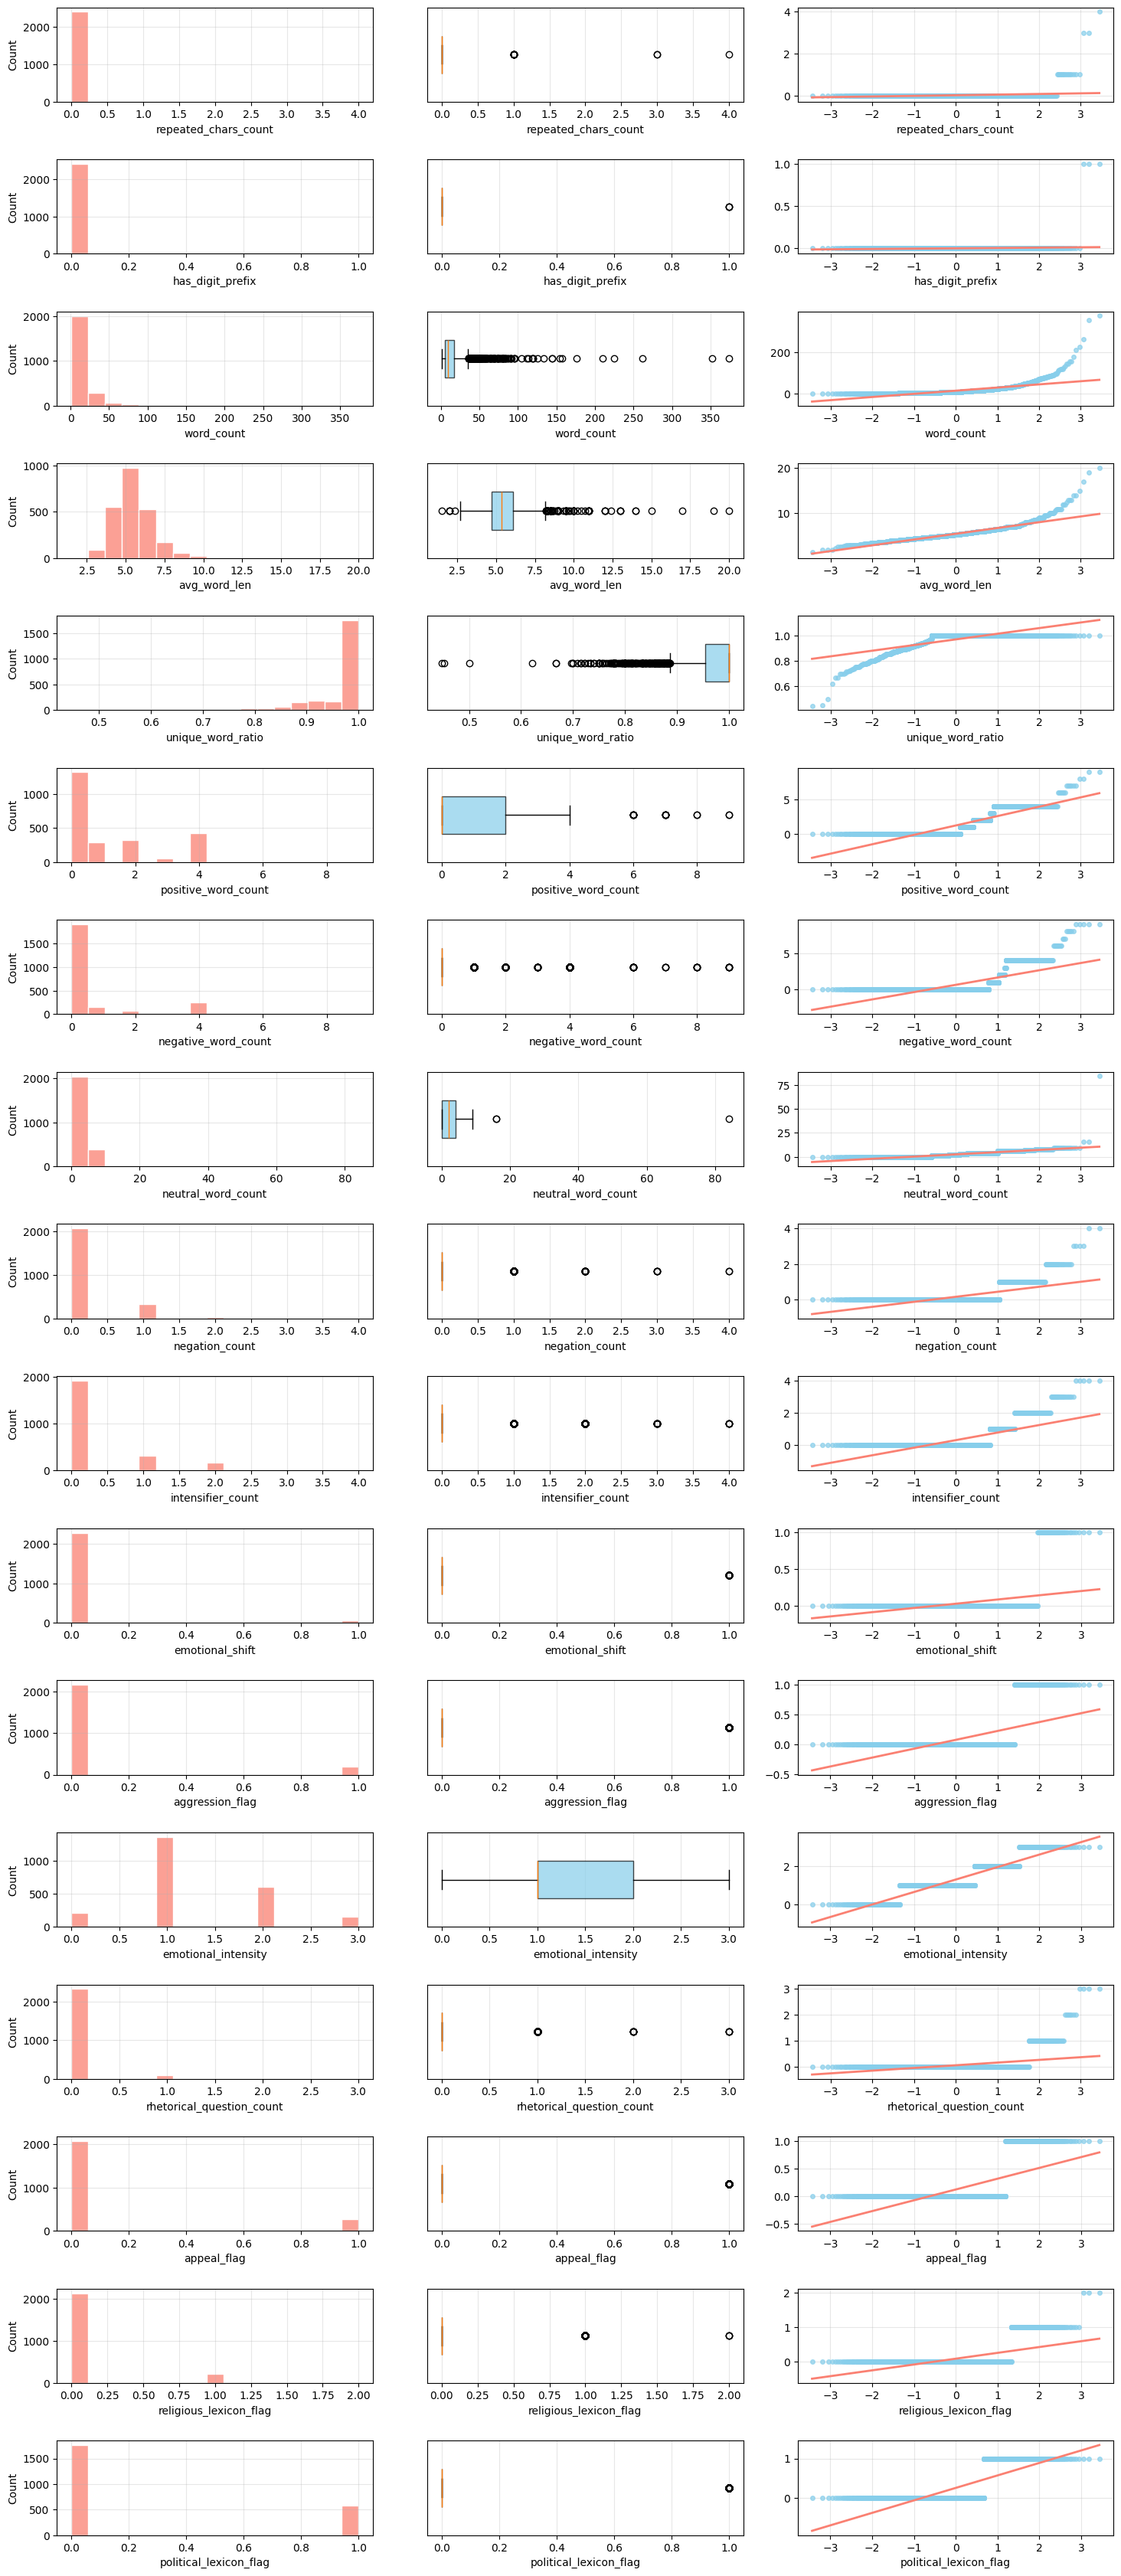

In [63]:
plot_hist_boxplot(X_train, X_train.columns)

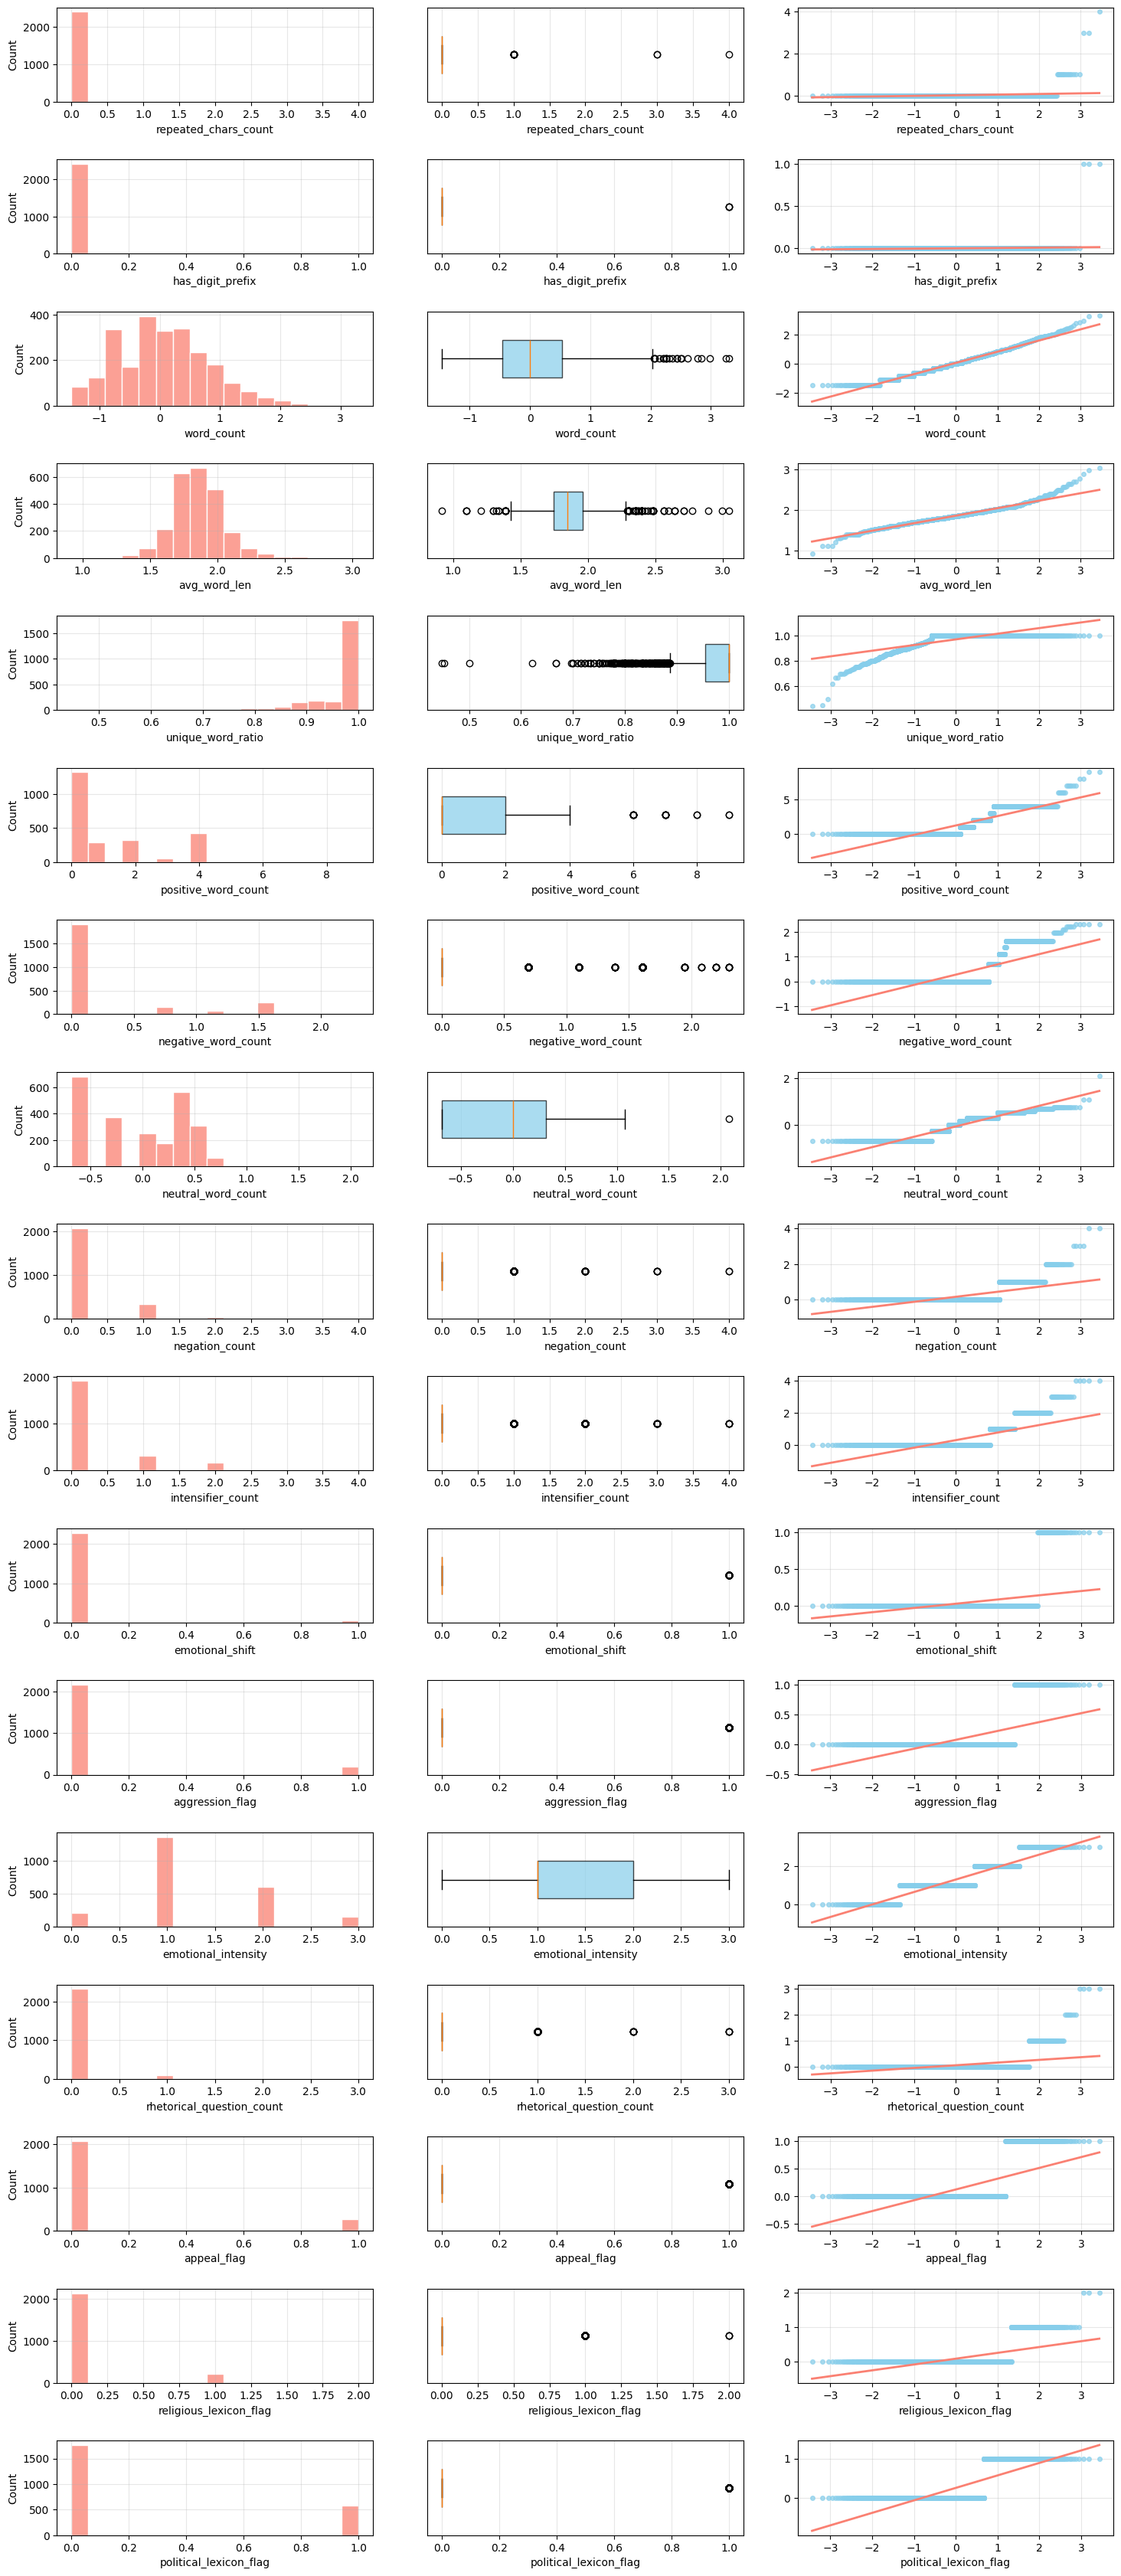

In [64]:
scaler_json = {
    "Chain":{
        'word_count': ['Log1p','RobustScaler'],
        'avg_word_len': ['Log1p'],
        'negative_word_count': ['Log1p'],
        'neutral_word_count': ['Log1p','RobustScaler'],
    }
}

X_train_scaler = normalize_data_with_scalers(X_train, scaler_json)
X_test_scaler = normalize_data_with_scalers(X_test, scaler_json)
plot_hist_boxplot(X_train_scaler, X_train_scaler.columns)

In [65]:
X_train_scaler

,repeated_chars_count,has_digit_prefix,word_count,avg_word_len,unique_word_ratio,positive_word_count,negative_word_count,neutral_word_count,negation_count,intensifier_count,emotional_shift,aggression_flag,emotional_intensity,rhetorical_question_count,appeal_flag,religious_lexicon_flag,political_lexicon_flag
1056,0,0,0.165956,1.645156,1.000000,0,0.000000,-0.251930,0,0,0.0,0.0,0.0,0,0.0,0.0,1.0
858,0,0,0.086755,1.840550,0.900000,2,0.000000,0.317394,0,1,0.0,0.0,1.0,0,0.0,0.0,0.0
631,0,0,-1.095903,1.945910,1.000000,1,0.000000,-0.682606,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0
1064,0,0,1.427816,1.856963,0.893617,0,0.000000,0.682606,1,0,0.0,0.0,1.0,0,0.0,1.0,1.0
732,0,0,0.306270,1.752539,1.000000,0,1.098612,0.317394,1,0,0.0,0.0,1.0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2250,0,0,-0.095903,1.998096,1.000000,0,0.693147,0.317394,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0
2430,0,0,0.630930,1.746909,0.894737,0,0.000000,0.526456,1,0,0.0,0.0,1.0,0,0.0,0.0,1.0
1492,0,0,-0.095903,1.981001,1.000000,0,0.000000,-0.251930,0,0,0.0,0.0,1.0,0,0.0,0.0,1.0
551,0,0,-1.095903,2.014903,1.000000,0,0.000000,-0.251930,0,0,0.0,0.0,1.0,0,0.0,0.0,0.0


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.ensemble import (GradientBoostingClassifier,
                              RandomForestClassifier,
                              )
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (cross_val_score,
                                     cross_val_predict,
                                     cross_validate)

In [70]:
model = RandomForestClassifier()
model.fit(X_train_scaler,y_train)
y_pred = model.predict(X_test_scaler)

In [71]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    matthews_corrcoef
)

# test
y_pred_test = model.predict(X_test_scaler)

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_test))  
print("MCC:", matthews_corrcoef(y_test, y_pred_test))

print("\nClassification report (TEST):")
print(classification_report(y_test, y_pred_test, digits=3))  

Accuracy: 0.7211221122112211
Balanced accuracy: 0.6603340418758922
MCC: 0.5500207350946668

Classification report (TEST):
              precision    recall  f1-score   support

          -1      0.500     0.442     0.469       104
           0      0.655     0.670     0.662       227
           1      0.848     0.869     0.858       275

    accuracy                          0.721       606
   macro avg      0.668     0.660     0.663       606
weighted avg      0.716     0.721     0.718       606



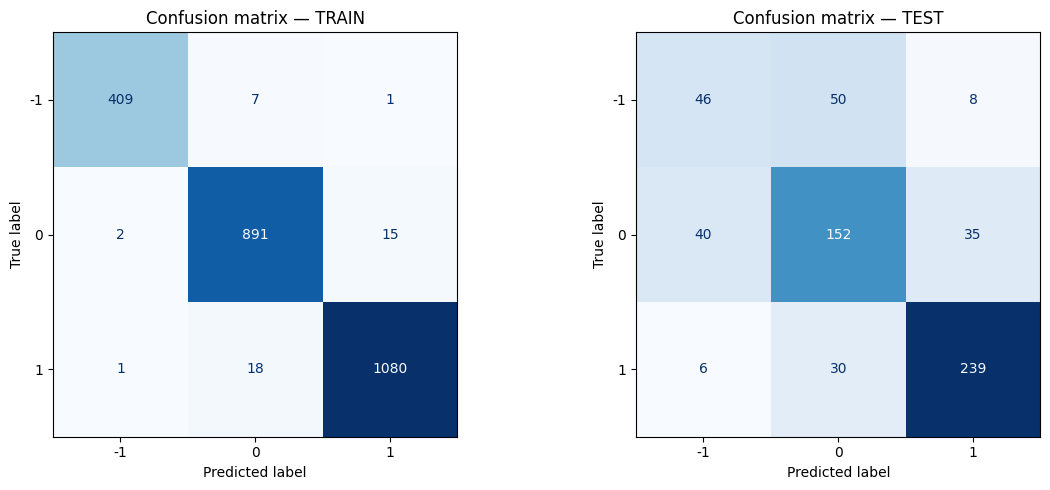

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = [-1, 0, 1]  

# Предсказания
y_pred_train = model.predict(X_train_scaler)
y_pred_test  = model.predict(X_test_scaler)

# Confusion matrices
cm_train = confusion_matrix(y_train, y_pred_train, labels=labels)
cm_test  = confusion_matrix(y_test,  y_pred_test,  labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)\
    .plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)  
axes[0].set_title("Confusion matrix — TRAIN")

ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)\
    .plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)  
axes[1].set_title("Confusion matrix — TEST")

plt.tight_layout()
plt.show()


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, f1_score, make_scorer
import numpy as np


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=34)

def objective(trial):
    params = {
        # Ограничиваем глубину — главный регуляризатор RF
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),

        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'random_state': 34,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    # Считаем обе метрики через CV
    ba_scores = cross_val_score(
        model, X_train_scaler, y_train,
        cv=cv,
        scoring='balanced_accuracy'
    )
    f1_scores = cross_val_score(
        model, X_train_scaler, y_train,
        cv=cv,
        scoring='f1_weighted'
    )

    ba_mean = ba_scores.mean()
    f1_mean = f1_scores.mean()


    trial.set_user_attr('balanced_accuracy', ba_mean)
    trial.set_user_attr('f1_weighted', f1_mean)

    return (ba_mean + f1_mean) / 2


study = optuna.create_study(direction='maximize')
study.optimize(
    objective,
    n_trials=80,
    n_jobs=1,
    show_progress_bar=True
)

print(f"Best combined score: {study.best_value:.4f}")
print(f"  Balanced Accuracy: {study.best_trial.user_attrs['balanced_accuracy']:.4f}")
print(f"  F1 Weighted:       {study.best_trial.user_attrs['f1_weighted']:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-04-05 20:22:53,216] A new study created in memory with name: no-name-ab5ac3a4-0302-454d-933b-dfe132d71f14
Best trial: 0. Best value: 0.714418:   1%|▏         | 1/80 [00:12<16:18, 12.38s/it]

[I 2026-04-05 20:23:05,600] Trial 0 finished with value: 0.7144182181103064 and parameters: {'max_depth': 6, 'n_estimators': 209, 'min_samples_split': 19, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.7144182181103064.


Best trial: 0. Best value: 0.714418:   2%|▎         | 2/80 [00:16<09:47,  7.53s/it]

[I 2026-04-05 20:23:09,736] Trial 1 finished with value: 0.7116664005115945 and parameters: {'max_depth': 11, 'n_estimators': 92, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.7144182181103064.


Best trial: 2. Best value: 0.716079:   4%|▍         | 3/80 [00:28<12:10,  9.49s/it]

...

[I 2026-04-05 20:31:53,913] Trial 77 finished with value: 0.7176031387616695 and parameters: {'max_depth': 15, 'n_estimators': 179, 'min_samples_split': 12, 'min_samples_leaf': 11, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 35 with value: 0.7196621277674856.


Best trial: 35. Best value: 0.719662:  99%|█████████▉| 79/80 [09:03<00:05,  5.21s/it]

[I 2026-04-05 20:31:56,358] Trial 78 finished with value: 0.7151038161224104 and parameters: {'max_depth': 10, 'n_estimators': 60, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 35 with value: 0.7196621277674856.


Best trial: 79. Best value: 0.719705: 100%|██████████| 80/80 [09:09<00:00,  6.87s/it]

[I 2026-04-05 20:32:02,600] Trial 79 finished with value: 0.7197045346295098 and parameters: {'max_depth': 14, 'n_estimators': 149, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 79 with value: 0.7197045346295098.
Best combined score: 0.7197
  Balanced Accuracy: 0.7108
  F1 Weighted:       0.7287
Best params: {'max_depth': 14, 'n_estimators': 149, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'class_weight': 'balanced'}


Balanced Accuracy : 0.7483
F1 Weighted       : 0.7557


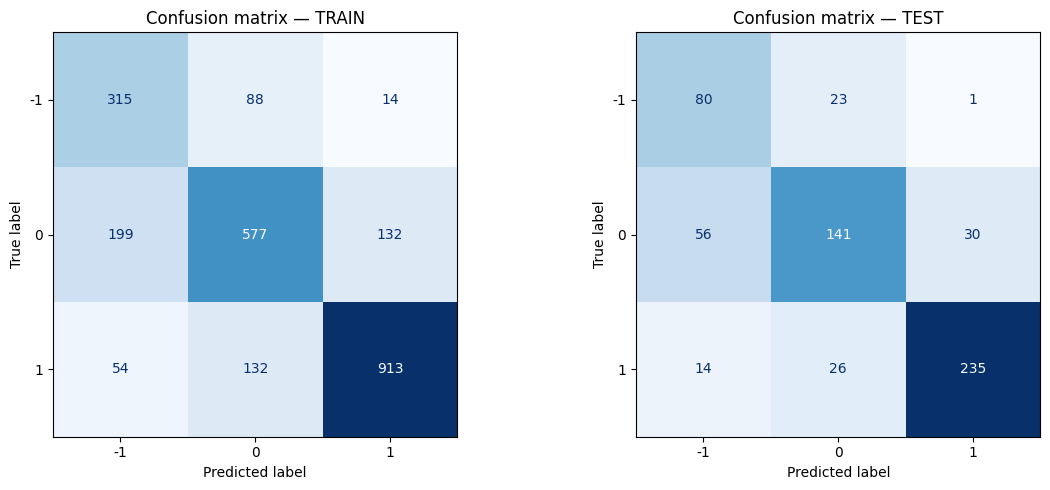

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt


best_params = {
    'max_depth': 14,
    'n_estimators': 149,
    'min_samples_split': 7,
    'min_samples_leaf': 9,
    'max_features': 'log2',
    'class_weight': 'balanced',
    'random_state': 34,
    'n_jobs': -1
}

model = RandomForestClassifier(**best_params)
model.fit(X_train_scaler, y_train)

# Метрики
y_pred_test = model.predict(X_test_scaler)
print(f"Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_test):.4f}")
print(f"F1 Weighted       : {f1_score(y_test, y_pred_test, average='weighted'):.4f}")

# Матрицы ошибок
labels = [-1, 0, 1]

y_pred_train = model.predict(X_train_scaler)
cm_train = confusion_matrix(y_train, y_pred_train, labels=labels)
cm_test  = confusion_matrix(y_test,  y_pred_test,  labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)\
    .plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Confusion matrix — TRAIN")

ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)\
    .plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Confusion matrix — TEST")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
## итак точность составилва ~ 75 % можно попробовать другие модели, или выделить топ 5-10 важных признаков и переобучить модель убрав шум. ожидаю что точность вырастет. 